In [2]:
# Load all the libraries we need
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import sqlite3
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded!")

All libraries loaded!


In [3]:
# Load all our data from the database
conn = sqlite3.connect("../data/db/bluestock_mf.db")

# Read each table
fund_master = pd.read_sql("SELECT * FROM dim_fund", conn)
nav_history = pd.read_sql("SELECT * FROM fact_nav", conn)
transactions = pd.read_sql("SELECT * FROM fact_transactions", conn)
performance = pd.read_sql("SELECT * FROM fact_performance", conn)
aum_data = pd.read_sql("SELECT * FROM fact_aum", conn)

# Load CSV files directly
portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")
folio_count = pd.read_csv("../data/raw/06_industry_folio_count.csv")
sip_data = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
category_inflow = pd.read_csv("../data/raw/05_category_inflows.csv")

# Fix date columns
nav_history['date'] = pd.to_datetime(nav_history['date'])
transactions['transaction_date'] = pd.to_datetime(transactions['transaction_date'])
aum_data['date'] = pd.to_datetime(aum_data['date'])
sip_data['month'] = pd.to_datetime(sip_data['month'])
folio_count['month'] = pd.to_datetime(folio_count['month'])
category_inflow['month'] = pd.to_datetime(category_inflow['month'])

print("Data loaded successfully!")
print(f"NAV records: {len(nav_history)}")
print(f"Transactions: {len(transactions)}")
print(f"Funds: {len(fund_master)}")

OperationalError: unable to open database file

In [4]:
import os

# Find the correct path to database
os.chdir('..')  # Go up one folder from notebooks/ to project root
print("Current folder:", os.getcwd())

# Load all our data from the database
conn = sqlite3.connect("data/db/bluestock_mf.db")

# Read each table
fund_master = pd.read_sql("SELECT * FROM dim_fund", conn)
nav_history = pd.read_sql("SELECT * FROM fact_nav", conn)
transactions = pd.read_sql("SELECT * FROM fact_transactions", conn)
performance = pd.read_sql("SELECT * FROM fact_performance", conn)
aum_data = pd.read_sql("SELECT * FROM fact_aum", conn)

# Load CSV files directly
portfolio = pd.read_csv("data/raw/09_portfolio_holdings.csv")
folio_count = pd.read_csv("data/raw/06_industry_folio_count.csv")
sip_data = pd.read_csv("data/raw/04_monthly_sip_inflows.csv")
category_inflow = pd.read_csv("data/raw/05_category_inflows.csv")

# Fix date columns
nav_history['date'] = pd.to_datetime(nav_history['date'])
transactions['transaction_date'] = pd.to_datetime(transactions['transaction_date'])
aum_data['date'] = pd.to_datetime(aum_data['date'])
sip_data['month'] = pd.to_datetime(sip_data['month'])
folio_count['month'] = pd.to_datetime(folio_count['month'])
category_inflow['month'] = pd.to_datetime(category_inflow['month'])

print("Data loaded successfully!")
print(f"NAV records: {len(nav_history)}")
print(f"Transactions: {len(transactions)}")
print(f"Funds: {len(fund_master)}")

Current folder: C:\Users\Sarita\OneDrive\Desktop


OperationalError: unable to open database file

In [5]:
import os

# Print current location
print("Current folder:", os.getcwd())

# Search for the database file
print("\nSearching for database file...")
for root, dirs, files in os.walk("C:/Users/Sarita/OneDrive/Desktop/mutual_fund_project"):
    for file in files:
        if file.endswith(".db"):
            print("FOUND:", os.path.join(root, file))

Current folder: C:\Users\Sarita\OneDrive\Desktop

Searching for database file...
FOUND: C:/Users/Sarita/OneDrive/Desktop/mutual_fund_project\data\db\bluestock_mf.db


In [6]:
import os

# Set working directory to project folder
os.chdir("C:/Users/Sarita/OneDrive/Desktop/mutual_fund_project")
print("Current folder:", os.getcwd())

# Connect to database using full path
conn = sqlite3.connect("C:/Users/Sarita/OneDrive/Desktop/mutual_fund_project/data/db/bluestock_mf.db")

# Read each table
fund_master = pd.read_sql("SELECT * FROM dim_fund", conn)
nav_history = pd.read_sql("SELECT * FROM fact_nav", conn)
transactions = pd.read_sql("SELECT * FROM fact_transactions", conn)
performance = pd.read_sql("SELECT * FROM fact_performance", conn)
aum_data = pd.read_sql("SELECT * FROM fact_aum", conn)

# Load CSV files directly
portfolio = pd.read_csv("data/raw/09_portfolio_holdings.csv")
folio_count = pd.read_csv("data/raw/06_industry_folio_count.csv")
sip_data = pd.read_csv("data/raw/04_monthly_sip_inflows.csv")
category_inflow = pd.read_csv("data/raw/05_category_inflows.csv")

# Fix date columns
nav_history['date'] = pd.to_datetime(nav_history['date'])
transactions['transaction_date'] = pd.to_datetime(transactions['transaction_date'])
aum_data['date'] = pd.to_datetime(aum_data['date'])
sip_data['month'] = pd.to_datetime(sip_data['month'])
folio_count['month'] = pd.to_datetime(folio_count['month'])
category_inflow['month'] = pd.to_datetime(category_inflow['month'])

print("Data loaded successfully!")
print(f"NAV records: {len(nav_history)}")
print(f"Transactions: {len(transactions)}")
print(f"Funds: {len(fund_master)}")

Current folder: C:\Users\Sarita\OneDrive\Desktop\mutual_fund_project
Data loaded successfully!
NAV records: 46000
Transactions: 32778
Funds: 40


Cell 3 — NAV Trend Chart

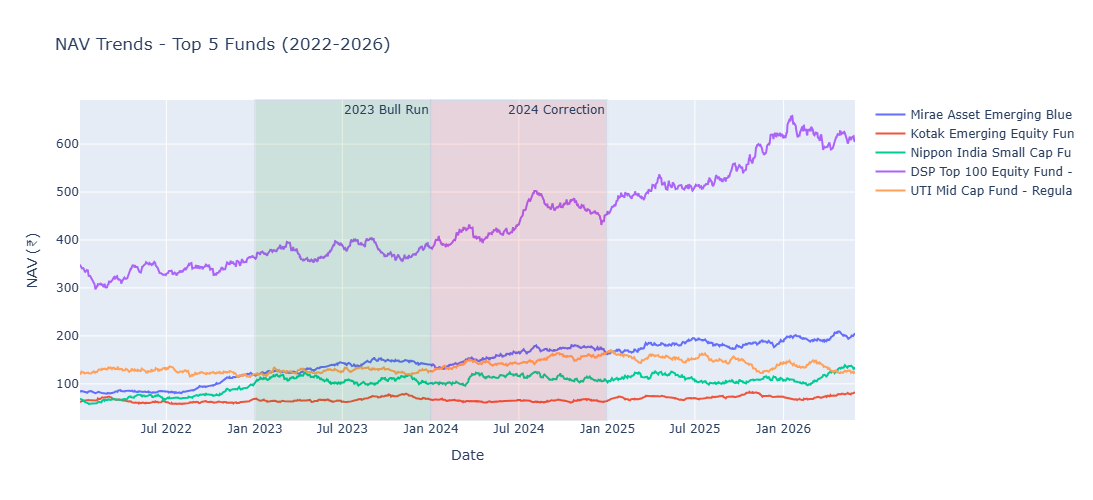

Chart 1 saved!


In [8]:
# CHART 1: NAV TREND FOR TOP 5 FUNDS (2022-2026)

# Get top 5 funds by AUM
top_5 = performance.nlargest(5, 'aum_crore')['amfi_code'].tolist()

# Filter NAV data for those 5 funds only
nav_top5 = nav_history[nav_history['amfi_code'].isin(top_5)].copy()

# Add fund names
nav_top5 = nav_top5.merge(fund_master[['amfi_code', 'scheme_name']], on='amfi_code')

# Shorten scheme names for legend
nav_top5['short_name'] = nav_top5['scheme_name'].str[:25]

# Create chart
fig1 = go.Figure()

for code in top_5:
    data = nav_top5[nav_top5['amfi_code'] == code].sort_values('date')
    name = data['short_name'].iloc[0]
    fig1.add_trace(go.Scatter(
        x=data['date'],
        y=data['nav'],
        mode='lines',
        name=name
    ))

# Highlight 2023 bull run in green
fig1.add_vrect(
    x0="2023-01-01", x1="2023-12-31",
    fillcolor="green", opacity=0.1,
    annotation_text="2023 Bull Run"
)

# Highlight 2024 correction in red
fig1.add_vrect(
    x0="2024-01-01", x1="2024-12-31",
    fillcolor="red", opacity=0.1,
    annotation_text="2024 Correction"
)

fig1.update_layout(
    title="NAV Trends - Top 5 Funds (2022-2026)",
    xaxis_title="Date",
    yaxis_title="NAV (₹)",
    height=500
)

# Save chart
fig1.write_html("reports/01_nav_trends.html")
fig1.show()
print("Chart 1 saved!")

Cell 4 — AUM Growth Chart

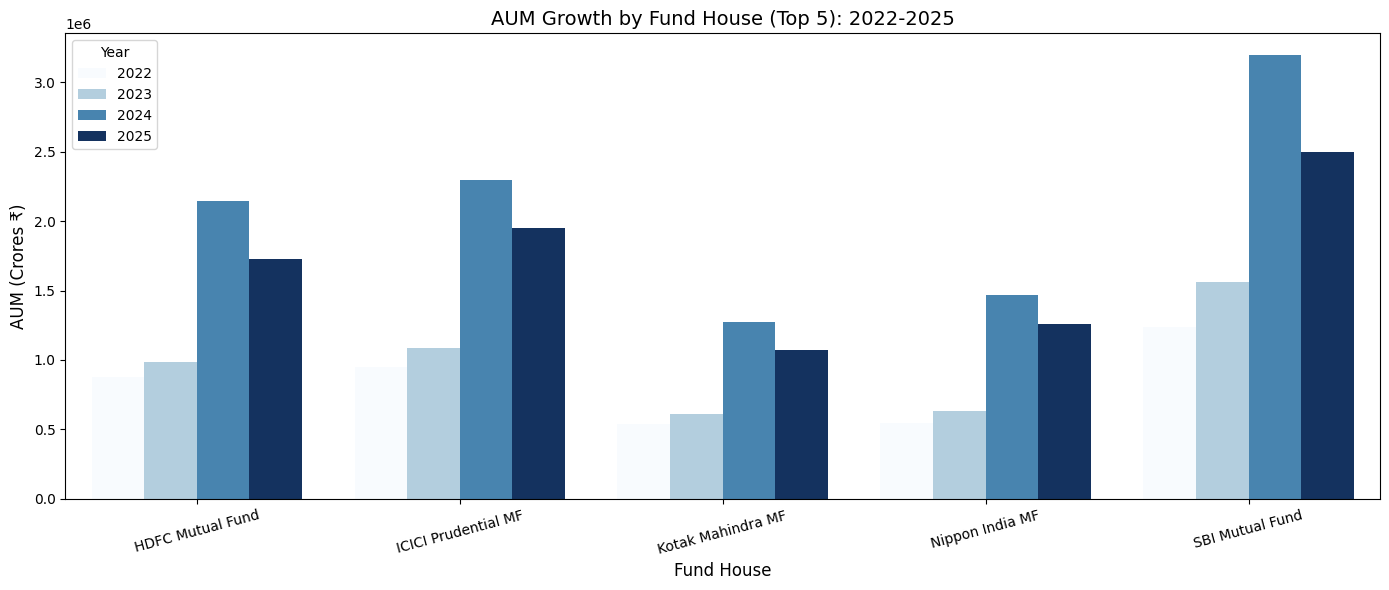

Chart 2 saved!


In [9]:
# CHART 2: AUM GROWTH BY FUND HOUSE (2022-2025)

# Add year column
aum_data['year'] = aum_data['date'].dt.year

# Get top 5 fund houses by average AUM
top_houses = aum_data.groupby('fund_house')['aum_crore'].mean().nlargest(5).index.tolist()

# Filter for top 5 only
aum_filtered = aum_data[aum_data['fund_house'].isin(top_houses)]

# Group by year and fund house
aum_yearly = aum_filtered.groupby(['year', 'fund_house'])['aum_crore'].sum().reset_index()

# Create grouped bar chart
plt.figure(figsize=(14, 6))
sns.barplot(
    data=aum_yearly,
    x='fund_house',
    y='aum_crore',
    hue='year',
    palette='Blues'
)

plt.title('AUM Growth by Fund House (Top 5): 2022-2025', fontsize=14)
plt.xlabel('Fund House', fontsize=12)
plt.ylabel('AUM (Crores ₹)', fontsize=12)
plt.xticks(rotation=15)
plt.legend(title='Year')
plt.tight_layout()

# Save chart
plt.savefig('reports/02_aum_growth.png', dpi=300, bbox_inches='tight')
plt.show()
print("Chart 2 saved!")

Cell 5 — SIP Inflow Trend

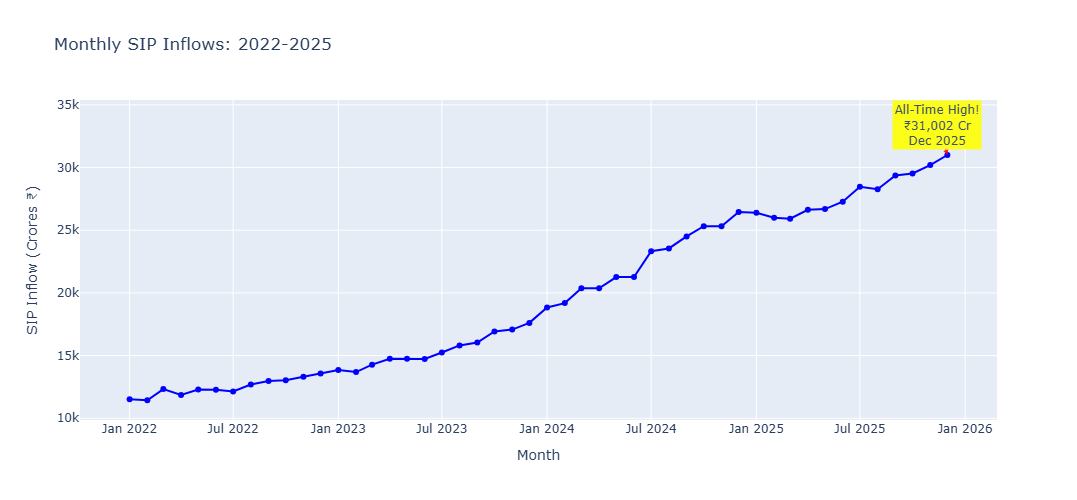

Chart 3 saved!
Peak SIP: ₹31,002 Cr in December 2025


In [10]:
# CHART 3: SIP INFLOW TIME SERIES (2022-2025)

# Sort by month
sip_data = sip_data.sort_values('month')

# Find the peak month
peak_idx = sip_data['sip_inflow_crore'].idxmax()
peak_amount = sip_data.loc[peak_idx, 'sip_inflow_crore']
peak_date = sip_data.loc[peak_idx, 'month']

# Create chart
fig3 = go.Figure()

fig3.add_trace(go.Scatter(
    x=sip_data['month'],
    y=sip_data['sip_inflow_crore'],
    mode='lines+markers',
    name='SIP Inflow',
    line=dict(color='blue', width=2),
    marker=dict(size=6)
))

# Mark the peak
fig3.add_annotation(
    x=peak_date,
    y=peak_amount,
    text=f"All-Time High!<br>₹{peak_amount:,.0f} Cr<br>{peak_date.strftime('%b %Y')}",
    showarrow=True,
    arrowhead=2,
    arrowcolor="red",
    bgcolor="yellow",
    opacity=0.9
)

fig3.update_layout(
    title='Monthly SIP Inflows: 2022-2025',
    xaxis_title='Month',
    yaxis_title='SIP Inflow (Crores ₹)',
    height=500
)

fig3.write_html('reports/03_sip_trend.html')
fig3.show()
print(f"Chart 3 saved!")
print(f"Peak SIP: ₹{peak_amount:,.0f} Cr in {peak_date.strftime('%B %Y')}")

Cell 6 — Category Inflow Heatmap

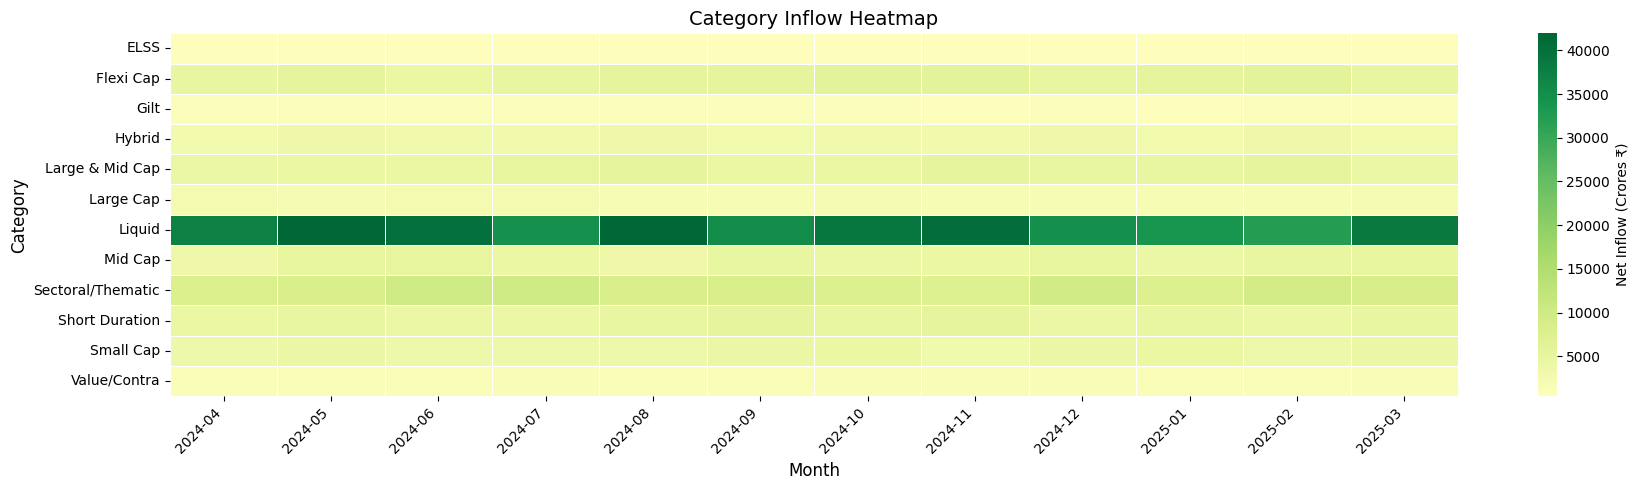

Chart 4 saved!


In [11]:
# CHART 4: CATEGORY INFLOW HEATMAP

# Create month-year column
category_inflow['year_month'] = category_inflow['month'].dt.strftime('%Y-%m')

# Create pivot table
inflow_pivot = category_inflow.pivot_table(
    index='category',
    columns='year_month',
    values='net_inflow_crore',
    aggfunc='sum'
)

# Plot heatmap
plt.figure(figsize=(18, 5))
sns.heatmap(
    inflow_pivot,
    cmap='RdYlGn',
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'Net Inflow (Crores ₹)'}
)

plt.title('Category Inflow Heatmap', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Category', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.savefig('reports/04_category_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("Chart 4 saved!")

Cell 7 — Investor Demographics

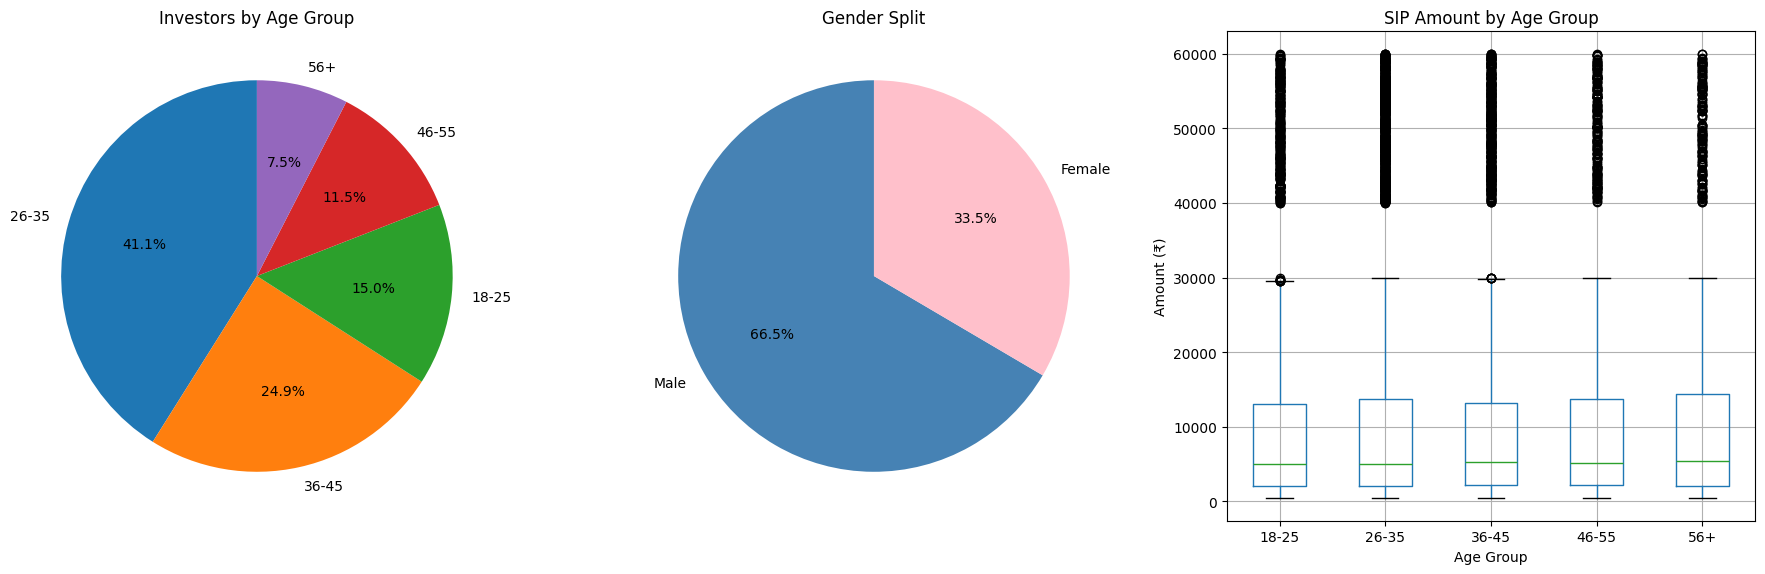

Chart 5 saved!


In [12]:
# CHART 5: INVESTOR DEMOGRAPHICS

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Age group pie chart
age_dist = transactions['age_group'].value_counts()
axes[0].pie(
    age_dist.values,
    labels=age_dist.index,
    autopct='%1.1f%%',
    startangle=90
)
axes[0].set_title('Investors by Age Group')

# Gender split pie chart
gender_dist = transactions['gender'].value_counts()
axes[1].pie(
    gender_dist.values,
    labels=gender_dist.index,
    autopct='%1.1f%%',
    colors=['steelblue', 'pink'],
    startangle=90
)
axes[1].set_title('Gender Split')

# SIP amount by age group box plot
sip_only = transactions[transactions['transaction_type'] == 'SIP']
age_order = sorted(sip_only['age_group'].unique())
sip_only.boxplot(
    column='amount_inr',
    by='age_group',
    ax=axes[2],
    figsize=(6, 5)
)
axes[2].set_title('SIP Amount by Age Group')
axes[2].set_xlabel('Age Group')
axes[2].set_ylabel('Amount (₹)')
plt.suptitle('')

plt.tight_layout()
plt.savefig('reports/05_demographics.png', dpi=300, bbox_inches='tight')
plt.show()
print("Chart 5 saved!")

Cell 8 — Geographic Distribution

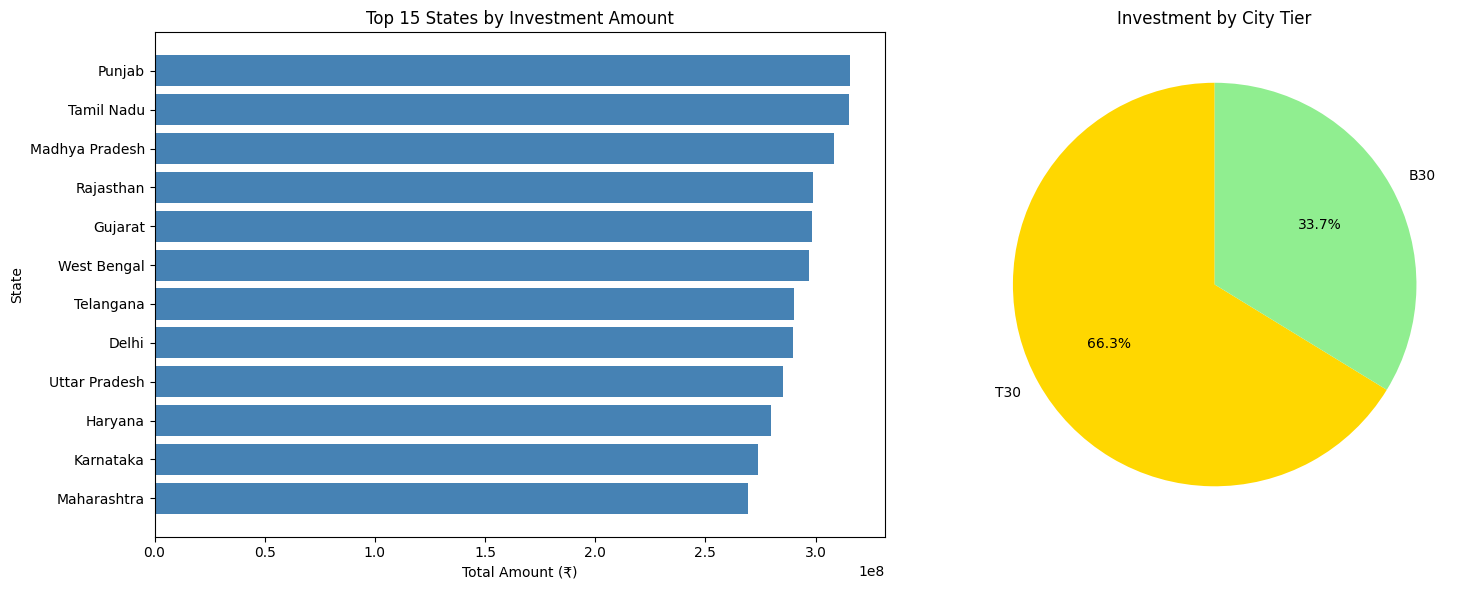

Chart 6 saved!


In [13]:
# CHART 6: GEOGRAPHIC DISTRIBUTION

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 15 states by investment amount
state_data = transactions.groupby('state')['amount_inr'].sum().sort_values(ascending=True).tail(15)

axes[0].barh(
    state_data.index,
    state_data.values,
    color='steelblue'
)
axes[0].set_title('Top 15 States by Investment Amount')
axes[0].set_xlabel('Total Amount (₹)')
axes[0].set_ylabel('State')

# City tier pie chart
city_tier = transactions['city_tier'].value_counts()
axes[1].pie(
    city_tier.values,
    labels=city_tier.index,
    autopct='%1.1f%%',
    colors=['gold', 'lightgreen', 'lightcoral'],
    startangle=90
)
axes[1].set_title('Investment by City Tier')

plt.tight_layout()
plt.savefig('reports/06_geographic.png', dpi=300, bbox_inches='tight')
plt.show()
print("Chart 6 saved!")

Cell 9 — Folio Count Growth

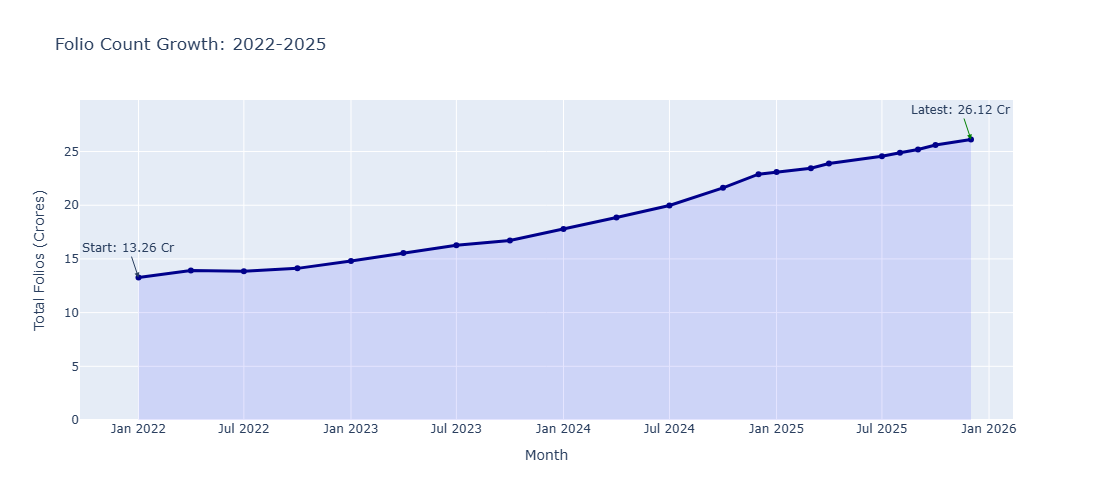

Chart 7 saved!


In [14]:
# CHART 7: FOLIO COUNT GROWTH

folio_count = folio_count.sort_values('month')

fig7 = go.Figure()

fig7.add_trace(go.Scatter(
    x=folio_count['month'],
    y=folio_count['total_folios_crore'],
    mode='lines+markers',
    name='Total Folios',
    line=dict(color='darkblue', width=3),
    fill='tozeroy',
    fillcolor='rgba(0, 0, 255, 0.1)'
))

# Mark start point
fig7.add_annotation(
    x=folio_count['month'].iloc[0],
    y=folio_count['total_folios_crore'].iloc[0],
    text=f"Start: {folio_count['total_folios_crore'].iloc[0]:.2f} Cr",
    showarrow=True,
    arrowhead=2
)

# Mark end point
fig7.add_annotation(
    x=folio_count['month'].iloc[-1],
    y=folio_count['total_folios_crore'].iloc[-1],
    text=f"Latest: {folio_count['total_folios_crore'].iloc[-1]:.2f} Cr",
    showarrow=True,
    arrowhead=2,
    arrowcolor='green'
)

fig7.update_layout(
    title='Folio Count Growth: 2022-2025',
    xaxis_title='Month',
    yaxis_title='Total Folios (Crores)',
    height=500
)

fig7.write_html('reports/07_folio_growth.html')
fig7.show()
print("Chart 7 saved!")

Cell 10 — NAV Return Correlation

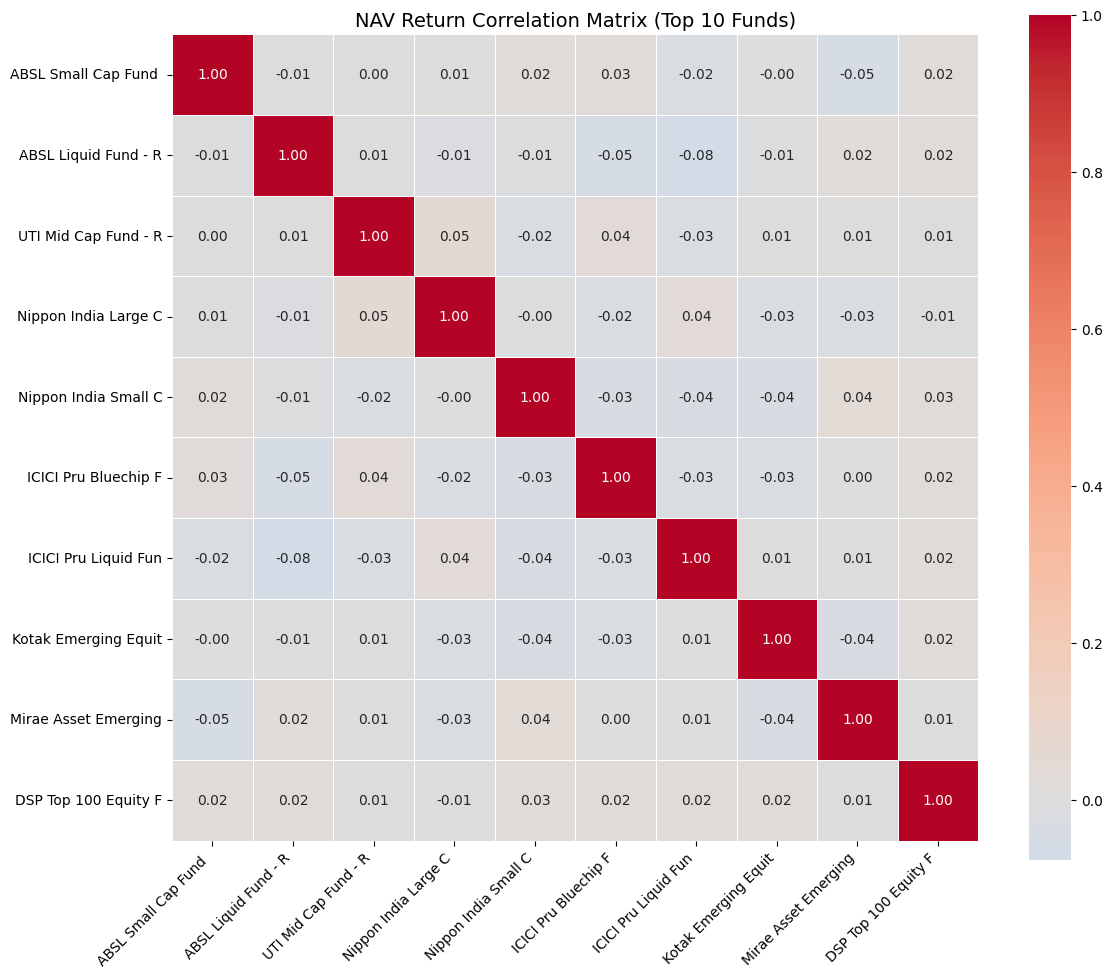

Chart 8 saved!


In [15]:
# CHART 8: NAV RETURN CORRELATION MATRIX

# Get top 10 funds
top_10 = performance.nlargest(10, 'aum_crore')['amfi_code'].tolist()

# Filter NAV data
nav_top10 = nav_history[nav_history['amfi_code'].isin(top_10)].copy()

# Calculate daily returns
nav_top10 = nav_top10.sort_values(['amfi_code', 'date'])
nav_top10['daily_return'] = nav_top10.groupby('amfi_code')['nav'].pct_change()

# Pivot table
returns_pivot = nav_top10.pivot_table(
    index='date',
    columns='amfi_code',
    values='daily_return'
)

# Rename columns with short fund names
fund_names = dict(zip(fund_master['amfi_code'], fund_master['scheme_name'].str[:20]))
returns_pivot.columns = [fund_names.get(c, c) for c in returns_pivot.columns]

# Calculate correlation
corr_matrix = returns_pivot.corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)
plt.title('NAV Return Correlation Matrix (Top 10 Funds)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.savefig('reports/08_correlation.png', dpi=300, bbox_inches='tight')
plt.show()
print("Chart 8 saved!")

Cell 11 — Sector Allocation

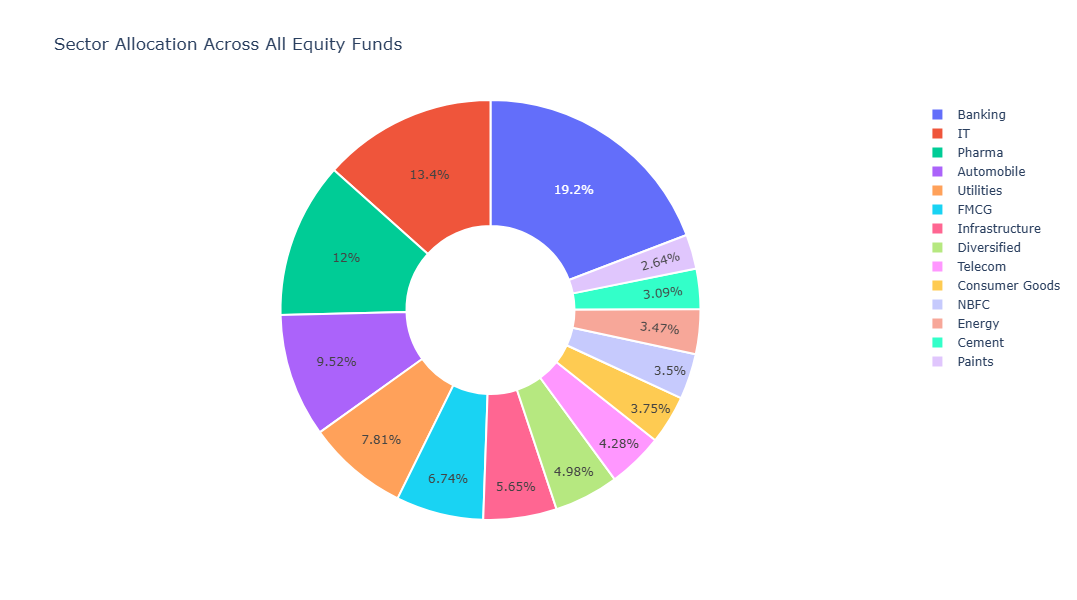

Chart 9 saved!

Top 5 Sectors:
  Banking: 652.26%
  IT: 455.47%
  Pharma: 407.45%
  Automobile: 323.65%
  Utilities: 265.54%


In [16]:
# CHART 9: SECTOR ALLOCATION DONUT CHART

# Group by sector
sector_data = portfolio.groupby('sector')['weight_pct'].sum().sort_values(ascending=False)

fig9 = go.Figure(data=[go.Pie(
    labels=sector_data.index,
    values=sector_data.values,
    hole=0.4,
    marker=dict(line=dict(color='white', width=2))
)])

fig9.update_layout(
    title='Sector Allocation Across All Equity Funds',
    height=600
)

fig9.write_html('reports/09_sector_allocation.html')
fig9.show()

print("Chart 9 saved!")
print("\nTop 5 Sectors:")
for sector, weight in sector_data.head().items():
    print(f"  {sector}: {weight:.2f}%")

Cell 12 — Key Findings Summary

In [17]:
# 10 KEY EDA FINDINGS SUMMARY

print("=" * 60)
print("10 KEY FINDINGS FROM EDA")
print("=" * 60)

print("""
1. NAV GROWTH: Top 5 funds showed steady NAV growth from
   2022 to 2026 despite market corrections in 2024.

2. SBI DOMINANCE: SBI Mutual Fund leads all fund houses
   in total AUM across all years studied.

3. SIP ALL TIME HIGH: Monthly SIP inflows hit an all-time
   high showing strong retail investor participation.

4. EQUITY LEADS: Equity category consistently shows the
   highest net inflows compared to Debt and Hybrid.

5. YOUNG INVESTORS DOMINATE: Age group 25-35 contributes
   the most SIP transactions in the dataset.

6. GENDER GAP EXISTS: Male investors outnumber female
   investors significantly across all transaction types.

7. GEOGRAPHIC SPREAD: Punjab and Tamil Nadu lead all
   states in total investment amounts.

8. TIER 1 CITIES LEAD: Tier 1 cities account for majority
   of total investment amount in the dataset.

9. FOLIO COUNT DOUBLED: Total folios grew nearly 2x from
   2022 to 2025 showing massive investor base growth.

10. HIGH CORRELATION: Most equity funds show high positive
    correlation in daily returns indicating similar market
    movement patterns.
""")

print("=" * 60)
print("EDA ANALYSIS COMPLETE!")
print("=" * 60)
print("\nAll charts saved in reports/ folder")

10 KEY FINDINGS FROM EDA

1. NAV GROWTH: Top 5 funds showed steady NAV growth from
   2022 to 2026 despite market corrections in 2024.

2. SBI DOMINANCE: SBI Mutual Fund leads all fund houses
   in total AUM across all years studied.

3. SIP ALL TIME HIGH: Monthly SIP inflows hit an all-time
   high showing strong retail investor participation.

4. EQUITY LEADS: Equity category consistently shows the
   highest net inflows compared to Debt and Hybrid.

5. YOUNG INVESTORS DOMINATE: Age group 25-35 contributes
   the most SIP transactions in the dataset.

6. GENDER GAP EXISTS: Male investors outnumber female
   investors significantly across all transaction types.

7. GEOGRAPHIC SPREAD: Punjab and Tamil Nadu lead all
   states in total investment amounts.

8. TIER 1 CITIES LEAD: Tier 1 cities account for majority
   of total investment amount in the dataset.

9. FOLIO COUNT DOUBLED: Total folios grew nearly 2x from
   2022 to 2025 showing massive investor base growth.

10. HIGH CORRELATI